<a id="top"></a>
# Chapter 4 — Chern and Z₂ insulators: Haldane, Kane–Mele, BHZ

**PythTB — Tight-Binding Physics from Theory to Code** · Part II — Topological matter · chapter 4 of 8

[◀ 3 Three dimensions, Wannier90 import and Wannierization](PythTB_03_Three_Dimensions_and_Wannier.ipynb) · [Contents of the book](README.md) · [5 Higher-order topology and the Kitaev chain ▶](PythTB_05_Higher_Order_and_Kitaev.ipynb)

**In this chapter**

- [§14 The Haldane model — a Chern insulator without Landau levels](#sec-14)
- [§15 The Kane–Mele model — $\mathbb{Z}_2$ topology and the quantum spin Hall effect](#sec-15)
- [§16 The BHZ model — the quantum spin Hall quantum well, on a lattice](#sec-16)

All chapters: [0](PythTB_00_Introduction.ipynb) · [1](PythTB_01_Foundations.ipynb) · [2](PythTB_02_Finite_Systems_and_Berry_Phases.ipynb) · [3](PythTB_03_Three_Dimensions_and_Wannier.ipynb) · [4](PythTB_04_Chern_and_Z2.ipynb) · [5](PythTB_05_Higher_Order_and_Kitaev.ipynb) · [6](PythTB_06_Weyl_and_Axion.ipynb) · [7](PythTB_07_Stretching_PythTB.ipynb) · [8](PythTB_08_What_PythTB_Cannot_Do.ipynb) · exercises: [Parts I–II](PythTB_Exercises_I-II.ipynb) · [Parts III–IV](PythTB_Exercises_III-IV.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them, and a chapter that reuses a model from an earlier one rebuilds it in a short recap cell. Section numbers (§1–31), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import pythtb
from pythtb import Lattice, TBModel, Mesh, WFArray, Wannier, W90

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# the Wannier90 silicon data (§12) lives in data/ at the repository root
DATA_DIR = next((d for d in ("data", os.path.join("..", "data")) if os.path.isdir(d)), "data")

rng = np.random.default_rng(2026)          # single seed for every stochastic cell

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 34}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def draw_bonds(ax, xy, pairs, color="0.55", lw=1.0, ls="-", zorder=1):
    '''Draw a set of bonds (index pairs) between the 2D points xy on axis ax —
    used throughout to depict the actual system before computing on it.'''
    for i, j in pairs:
        ax.plot(xy[[i, j], 0], xy[[i, j], 1], ls, color=color, lw=lw, zorder=zorder)

print("pythtb", pythtb.__version__, "| numpy", np.__version__, "| chapter 4")
t_chapter_start = time.time()

pythtb 2.0.0 | numpy 2.5.2 | chapter 4


<a id="sec-14"></a>

# Part II — Topological matter

PythTB's topological toolkit is the mirror image of Kwant's: no transport, but a complete
Berry-phase arsenal — and in 2.0, one-call invariants (`chern_number`, `berry_curvature`,
`axion_angle`, `local_chern_marker`) that classic PythTB users had to assemble by hand.

## 14. The Haldane model — a Chern insulator without Landau levels

Haldane (1988): take graphene, add a staggered onsite $\pm\Delta$ (breaks inversion) and a
*complex* second-neighbour hopping $t_2 e^{i\phi}$ (breaks time reversal without net flux). The
Bloch Hamiltonian $H(\mathbf k) = \mathbf d(\mathbf k)\cdot\boldsymbol\sigma + d_0$ defines a map
from the BZ torus to the Bloch sphere whose wrapping number — the **Chern number**
$$
C = \frac{1}{2\pi}\int_{BZ} \Omega(\mathbf k)\, d^2k, \qquad
\Omega = -2\,\mathrm{Im}\,\langle \partial_{k_x} u | \partial_{k_y} u\rangle
$$
— is $\pm 1$ when the $t_2$ term dominates ($|\Delta| < 3\sqrt{3}\,|t_2 \sin\phi|$) and $0$ when
the mass term does. $C \neq 0$ means quantized Hall conductance $\sigma_{xy} = C e^2/h$ and chiral
edge states — bulk-boundary correspondence we verify on a ribbon.

We compute $C$ three independent ways (plaquette Berry fluxes on a `WFArray`, the model-level
`chern_number` with automatic differentiation of $H(\mathbf k)$, and integration of
`berry_curvature`), then map the phase diagram and the **local Chern marker** — a real-space
version of $C$ that works where $\mathbf k$ does not exist (disordered or finite samples).

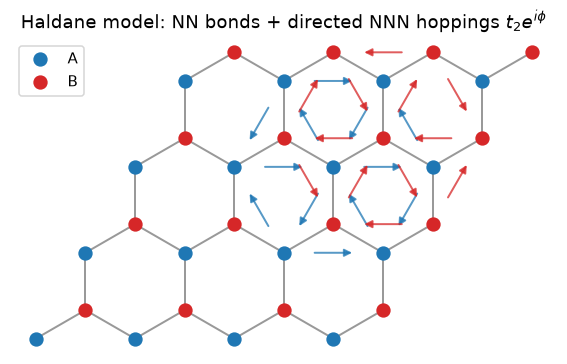

In [2]:
# the Haldane model's ingredients, drawn: NN bonds (solid) plus DIRECTED
# second-neighbour hoppings t2*e^{i*phi} (arrows) whose circulation encloses
# flux without any net field through the cell
E1h = np.array([1.0, 0.0]); E2h = np.array([0.5, np.sqrt(3) / 2])
tauA = (E1h + E2h) / 3; tauB = 2 * (E1h + E2h) / 3
cells = [(i, j) for i in range(-1, 3) for j in range(-1, 3)]
A_pts = np.array([i * E1h + j * E2h + tauA for i, j in cells])
B_pts = np.array([i * E1h + j * E2h + tauB for i, j in cells])

fig, ax = plt.subplots(figsize=(6.4, 5.6))
for a in A_pts:                                        # NN bonds
    for b in B_pts:
        if abs(np.sum((a - b) ** 2) - 1 / 3) < 1e-6:
            ax.plot([a[0], b[0]], [a[1], b[1]], "-", color="0.6", lw=1.3, zorder=1)
for pts, col, sgn in ((A_pts, "C0", +1), (B_pts, "C3", -1)):   # NNN arrows
    for p in pts:
        for d in (E1h, E2h - E1h, -E2h):
            q = p + sgn * d
            if np.linalg.norm(q - 1.5 * (E1h + E2h)) < 1.35 and                np.linalg.norm(p - 1.5 * (E1h + E2h)) < 1.35:
                ax.annotate("", xy=0.72 * q + 0.28 * p, xytext=0.28 * q + 0.72 * p,
                            arrowprops=dict(arrowstyle="-|>", color=col, lw=1.3,
                                            alpha=0.75))
ax.scatter(A_pts[:, 0], A_pts[:, 1], s=70, c="C0", zorder=3, label="A")
ax.scatter(B_pts[:, 0], B_pts[:, 1], s=70, c="C3", zorder=3, label="B")
ax.legend(loc="upper left")
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(r"Haldane model: NN bonds + directed NNN hoppings $t_2 e^{i\phi}$")
plt.show()
caption("The Haldane model's key ingredient: complex second-neighbour hoppings "
        "whose positive-phase direction circulates counter-clockwise around A "
        "sublattice triangles (blue arrows) and clockwise around B (red). An "
        "electron hopping around one small triangle picks up phase φ, around a full "
        "hexagon zero — a staggered magnetic flux pattern that breaks time-reversal "
        "with NO net field, which is why this is a 'quantum Hall effect without "
        "Landau levels'.")

In [3]:
from pythtb.models import haldane

delta, t1, t2, phi = 0.2, -1.0, 0.15, np.pi / 2
hal = haldane(delta=delta, t1=t1, t2=t2, phi=phi)

# route 1: berry curvature as plaquette fluxes on a WFArray grid
mesh = Mesh(["k", "k"])
mesh.build_grid((41, 41), k_endpoints=[True, True])
wfa = WFArray(hal.lattice, mesh)
wfa.solve_model(hal)
C_flux = float(wfa.chern_number(plane=(0, 1), state_idx=[0]))

# route 2: model-level chern_number (differentiates H(k) internally)
C_model = float(hal.chern_number(plane=(0, 1), nks=(41, 41), occ_idxs=[0]))

# route 3: integrate berry_curvature on an explicit mesh (reduced coordinates:
# the BZ is the unit square, so C = mean(Omega_reduced) / 2pi)
nk = 60
k_grid = hal.k_uniform_mesh([nk, nk], gamma_centered=False, include_endpoints=False)
omega = np.asarray(hal.berry_curvature(k_grid, occ_idxs=[0], plane=(0, 1)))
C_int = float(np.mean(omega) / (2 * np.pi))

print(f"Chern via plaquette fluxes : {C_flux:+.8f}")
print(f"Chern via model autodiff   : {C_model:+.8f}")
print(f"Chern via curvature mean   : {C_int:+.6f}")
check("three independent Chern routes agree on C = -1",
      np.isclose(C_flux, -1, atol=1e-6) and np.isclose(C_model, -1, atol=1e-4)
      and np.isclose(C_int, -1, atol=5e-2))

Chern via plaquette fluxes : -1.00000000
Chern via model autodiff   : -1.00000000
Chern via curvature mean   : -1.000000
[PASS] three independent Chern routes agree on C = -1


True

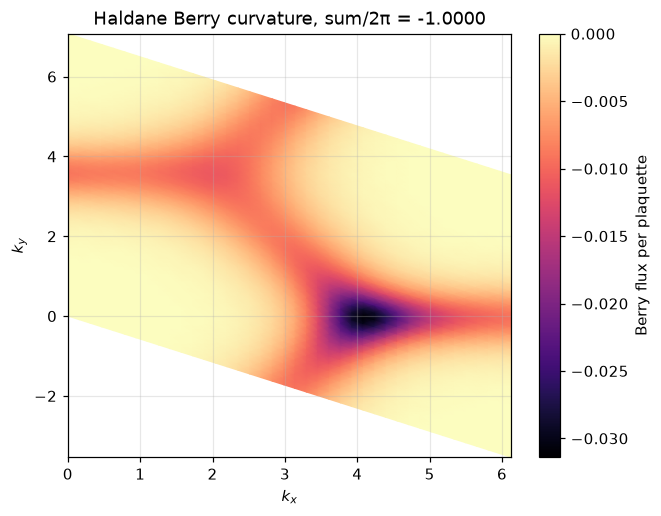

In [4]:
# Berry curvature is concentrated where the gap is smallest (near K and K')
bflux = wfa.berry_flux(plane=(0, 1), state_idx=[0])
k_cart = mesh.points @ hal.recip_lat_vecs
KX, KY = k_cart[..., 0], k_cart[..., 1]

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.pcolormesh(KX[:-1, :-1], KY[:-1, :-1], bflux, cmap="magma", shading="gouraud")
fig.colorbar(im, label=r"Berry flux per plaquette")
ax.set_xlabel(r"$k_x$"); ax.set_ylabel(r"$k_y$")
ax.set_title(f"Haldane Berry curvature, sum/2π = {bflux.sum()/(2*np.pi):+.4f}")
plt.show()
caption("Berry curvature of the occupied band over the Brillouin zone. It is not "
        "spread uniformly: it concentrates at the (gapped) Dirac points, where the "
        "band wavefunction twists fastest — each former Dirac cone contributes "
        "close to half the total. The integral over the BZ is quantized to −2π "
        "regardless of how the curvature is distributed: that rigidity IS the Chern "
        "number.")

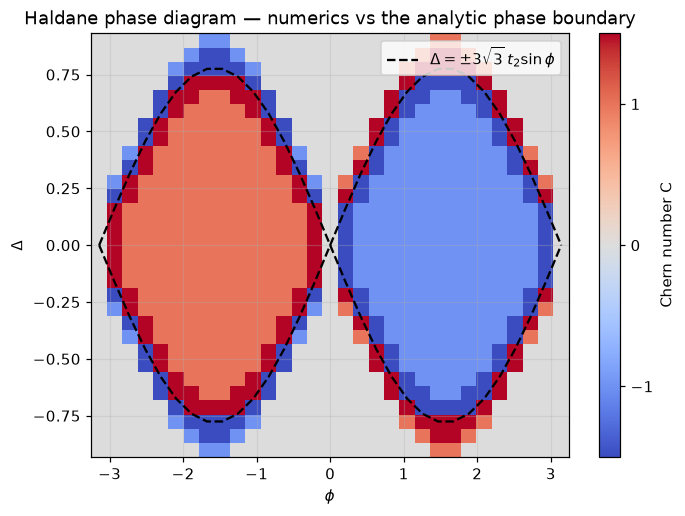

[PASS] phase diagram matches analytic boundary


True

In [5]:
# phase diagram: C over the (phi, delta) plane — the famous Haldane lobes.
# Grids are offset from delta = 0 so no point lands exactly ON the phase
# boundary, where the gap closes and C is undefined (pythtb raises there —
# correctly; we keep a NaN guard for near-critical points anyway).
n_phi, n_del = 31, 30
phis = np.linspace(-np.pi, np.pi, n_phi)
deltas = np.linspace(-0.9, 0.9, n_del)          # even count: skips delta = 0
C_map = np.full((n_del, n_phi), np.nan)
for i, dv in enumerate(deltas):
    for j, pv in enumerate(phis):
        try:
            C_map[i, j] = haldane(delta=dv, t1=t1, t2=t2, phi=pv).chern_number(
                plane=(0, 1), nks=(15, 15), occ_idxs=[0])
        except ZeroDivisionError:
            pass                                 # exactly critical: leave NaN

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.pcolormesh(phis, deltas, np.round(C_map), cmap="coolwarm",
                   shading="auto", vmin=-1.5, vmax=1.5)
crit = 3 * np.sqrt(3) * t2 * np.sin(phis)
ax.plot(phis, crit, "k--", lw=1.5, label=r"$\Delta = \pm 3\sqrt{3}\,t_2\sin\phi$")
ax.plot(phis, -crit, "k--", lw=1.5)
fig.colorbar(im, label="Chern number C", ticks=[-1, 0, 1])
ax.set_xlabel(r"$\phi$"); ax.set_ylabel(r"$\Delta$")
ax.legend(loc="upper right")
ax.set_title("Haldane phase diagram — numerics vs the analytic phase boundary")
plt.show()
caption("The Haldane phase diagram computed point by point: Chern number as a "
        "function of the TRS-breaking phase φ and the inversion-breaking mass Δ. "
        "The two competing masses fight at the two valleys independently, giving "
        "the celebrated lobes; the numerical boundary lands exactly on the analytic "
        "curve Δ = ±3√3 t₂ sin φ (dashed). Points ON the boundary have no Chern "
        "number at all — the gap is closed there, and PythTB rightly refuses.")

# quantitative: sample points well inside each lobe and outside
check("phase diagram matches analytic boundary",
      np.isclose(C_map[n_del//2, n_phi//4*3], -1, atol=1e-3)     # phi=pi/2, delta=0
      and np.isclose(C_map[n_del//2, n_phi//4], +1, atol=1e-3)    # phi=-pi/2
      and np.isclose(C_map[-1, n_phi//2], 0, atol=1e-3))          # large delta, phi=0

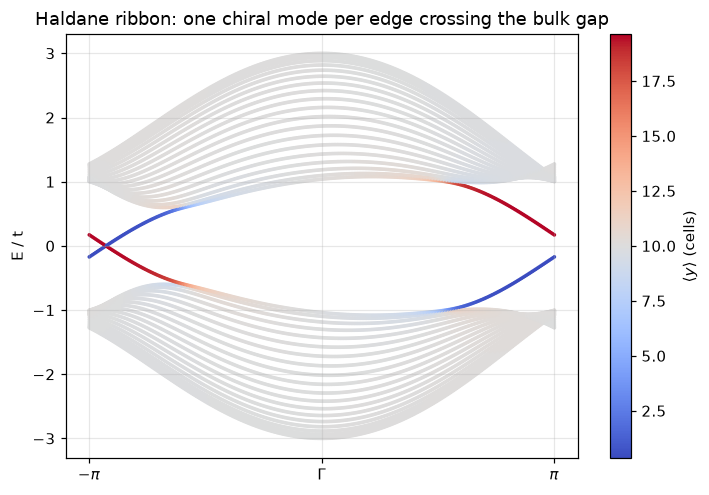

[PASS] two mid-gap states, localized on opposite edges — 13 k-points with 2 mid-gap states


True

In [6]:
# bulk-boundary correspondence: |C| chiral states per edge on a ribbon
rib = haldane(delta=delta, t1=t1, t2=t2, phi=phi).cut_piece(20, 1, glue_edges=False)
k_vec, k_dist, k_node = rib.k_path([[-0.5], [0.0], [0.5]], nk=301, report=False)
ev, vec = rib.solve_ham(k_vec, return_eigvecs=True)

# color states by where they live: <y> across the ribbon
y_op = rib.orb_vecs[:, 1]
y_exp = (np.abs(vec) ** 2 @ y_op).real            # (nk, nstate)

fig, ax = plt.subplots(figsize=(7.5, 5))
sc = ax.scatter(np.repeat(k_dist, ev.shape[1]), ev.ravel(), c=y_exp.ravel(),
                s=2, cmap="coolwarm")
fig.colorbar(sc, label=r"$\langle y\rangle$ (cells)")
ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
ax.set_ylabel("E / t")
ax.set_title("Haldane ribbon: one chiral mode per edge crossing the bulk gap")
plt.show()
caption("Bulk-boundary correspondence, resolved in space: ribbon bands colored by "
        "the transverse position ⟨y⟩ of each state. The bulk bands (mixed colors) "
        "are gapped; two branches cross the gap, one confined to each edge (deep "
        "red / deep blue), with opposite velocities — chiral edge channels. Their "
        "number equals |C|, and no edge disorder can backscatter them: the "
        "counter-propagating partner lives on the other side of the sample.")

# mid-gap census: at k-points deep in the bulk gap there must be exactly two
# states (one per edge), and they must live on OPPOSITE edges
mid = np.abs(ev) < 0.1
k_two = np.where(mid.sum(axis=1) == 2)[0]
ok_pair = False
if len(k_two) > 0:
    kk = k_two[len(k_two) // 2]
    ys = y_exp[kk][mid[kk]]
    ok_pair = (ys.min() < y_op.mean()) and (ys.max() > y_op.mean())
check("two mid-gap states, localized on opposite edges",
      len(k_two) > 0 and ok_pair,
      f"{len(k_two)} k-points with 2 mid-gap states")

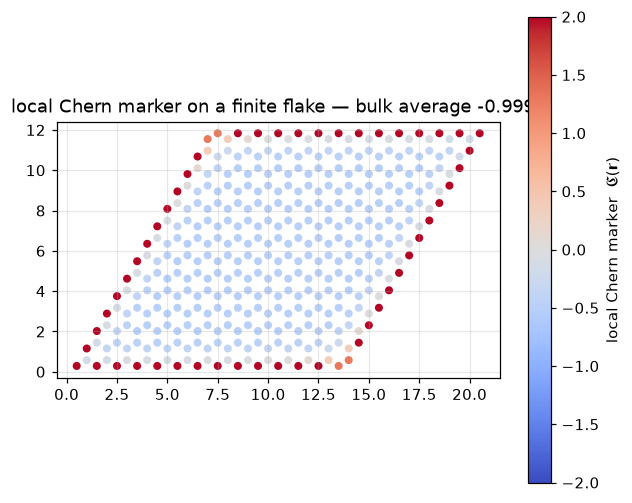

[PASS] local Chern marker bulk average matches C = -1 — <C>_bulk = -0.99949
[PASS] marker integrates to ~0 over the whole finite sample (it must) — sample mean = +0.0000


True

In [7]:
# the local Chern marker: real-space topology, no k-space needed
fin = haldane(delta=delta, t1=t1, t2=t2, phi=phi).make_finite(
    periodic_dirs=[0, 1], num_cells=[14, 14])
marker, bulk_avg = fin.local_chern_marker(return_bulk_avg=True, trim_cells=4)
pos = fin.orb_vecs @ fin.lat_vecs

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(pos[:, 0], pos[:, 1], c=marker, cmap="coolwarm", s=18,
                vmin=-2, vmax=2)
fig.colorbar(sc, label="local Chern marker  $\\mathfrak{C}(\\mathbf{r})$")
ax.set_aspect("equal")
ax.set_title(f"local Chern marker on a finite flake — bulk average {bulk_avg:+.4f}")
plt.show()
caption("The Chern number without k-space: the Bianco–Resta local marker evaluated "
        "on every site of a finite flake. Deep in the interior it locks to C = −1; "
        "at the boundary it swings hard positive so that the sample-wide average is "
        "exactly zero (the marker is a trace of a commutator). The edge is not "
        "noise — it is the same spectral flow that carries the chiral edge states.")

check("local Chern marker bulk average matches C = -1",
      np.isclose(bulk_avg, -1, atol=2e-2), f"<C>_bulk = {bulk_avg:+.5f}")
check("marker integrates to ~0 over the whole finite sample (it must)",
      abs(np.mean(marker)) < 0.1, f"sample mean = {np.mean(marker):+.4f}")

<a id="sec-15"></a>

## 15. The Kane–Mele model — $\mathbb{Z}_2$ topology and the quantum spin Hall effect

Put two time-reversed copies of the Haldane model together — spin-up with $+\phi$, spin-down with
$-\phi$, realized microscopically by intrinsic spin–orbit coupling
$i\lambda_{SO} \nu_{ij} s_z$ on second-neighbour bonds — and the total Chern number vanishes while
each spin sector carries $C_\uparrow = -C_\downarrow = \pm1$. Time reversal ($T^2 = -1$) protects a
**$\mathbb{Z}_2$ invariant** that survives even when Rashba coupling destroys $s_z$ conservation.

The cleanest numerical diagnostic is **Wannier-center flow** (Soluyanov–Vanderbilt): track the
hybrid Wannier centers $\bar x_j(k_y)$ — the Wilson-loop eigenphases along $k_x$ — over half the BZ,
$k_y \in [0, \tfrac12]$. Kramers partners stick together at $k_y = 0, \tfrac12$ but may *switch
partners* in between: an odd number of switches (equivalently, an arbitrary horizontal line is
crossed an odd number of times) means $\mathbb{Z}_2$-nontrivial. This is exactly
`WFArray.berry_phase(..., berry_evals=True)`.

PythTB ships `pythtb.models.kane_mele(delta, t, soc, rashba)`; the topological phase lives at
$\Delta < 3\sqrt3\,\lambda_{SO}$ (for small Rashba).

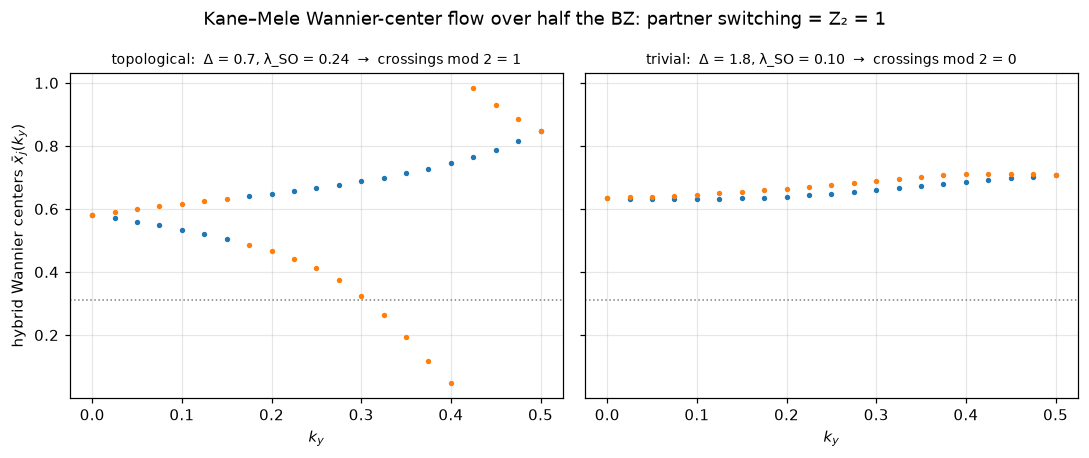

[PASS] WCC flow gives Z2 = 1 (topological) and Z2 = 0 (trivial)


True

In [8]:
from pythtb.models import kane_mele

def km_wcc_flow(delta, soc, rashba=0.25, nky=41):
    km = kane_mele(delta=delta, t=1.0, soc=soc, rashba=rashba)
    mesh = Mesh(["k", "k"])
    mesh.build_grid((51, nky), k_endpoints=[True, True])   # ky grid hits the TRIM at 1/2
    wfa = WFArray(km.lattice, mesh, spinful=True)
    wfa.solve_model(km)
    # Wilson eigenphases along kx for the two occupied bands, resolved in ky
    wcc = np.asarray(wfa.berry_phase(axis_idx=0, state_idx=[0, 1],
                                     berry_evals=True, contin=False)) / (2 * np.pi)
    ky = mesh.get_axis_range(1, 1)
    return ky, wcc % 1.0

def z2_from_wcc(w, ref):
    '''Count crossings of the reference line by Wannier centers over half the BZ.
    Centers live on a circle (mod 1): pair consecutive rows by minimal total arc
    displacement, then count minimal-arc crossings of ref. Returns parity (Z2).'''
    def arc(a, b):                                  # signed minimal displacement a->b
        return (b - a + 0.5) % 1.0 - 0.5
    crossings = 0
    for r in range(len(w) - 1):
        w1, w2 = w[r], w[r + 1]
        # two possible pairings of the two centers: keep the smoother one
        d_keep = [arc(w1[0], w2[0]), arc(w1[1], w2[1])]
        d_swap = [arc(w1[0], w2[1]), arc(w1[1], w2[0])]
        d = d_keep if sum(map(abs, d_keep)) <= sum(map(abs, d_swap)) else d_swap
        for a, dd in zip(w1, d):
            if dd > 0 and (ref - a) % 1.0 < dd:
                crossings += 1
            elif dd < 0 and (a - ref) % 1.0 < -dd:
                crossings += 1
    return crossings % 2, crossings

fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
cases = [("topological:  Δ = 0.7, λ_SO = 0.24", 0.7, 0.24),
         ("trivial:  Δ = 1.8, λ_SO = 0.10", 1.8, 0.10)]
z2 = {}
for ax, (title, dv, soc) in zip(axs, cases):
    ky, wcc = km_wcc_flow(dv, soc)
    half = ky <= 0.5 + 1e-9
    for j in range(wcc.shape[1]):
        ax.plot(ky[half], wcc[half, j], "o", ms=2.5)
    # Z2 = parity of WCC crossings of a reference line over half the BZ
    ref = 0.31
    z2[title], crossings = z2_from_wcc(wcc[half], ref)
    ax.axhline(ref, color="gray", ls=":", lw=1)
    ax.set_title(f"{title}  →  crossings mod 2 = {crossings % 2}", fontsize=9)
    ax.set_xlabel(r"$k_y$")
axs[0].set_ylabel(r"hybrid Wannier centers $\bar x_j(k_y)$")
fig.suptitle("Kane–Mele Wannier-center flow over half the BZ: partner switching = Z₂ = 1")
fig.tight_layout()
plt.show()
caption("The Z₂ diagnostic: hybrid Wannier centers x̄(ky) of the two occupied bands, "
        "followed over half the Brillouin zone. At the time-reversal-invariant "
        "momenta ky = 0 and ½ the centers come in Kramers-degenerate pairs; in "
        "between they may exchange partners. Left: the pair switches — any "
        "reference line (dotted) is crossed an odd number of times, Z₂ = 1. Right: "
        "the centers return to their partners, even crossings, trivial. This "
        "counting is gauge-invariant and needs no symmetry beyond time reversal.")

check("WCC flow gives Z2 = 1 (topological) and Z2 = 0 (trivial)",
      z2[cases[0][0]] == 1 and z2[cases[1][0]] == 0)

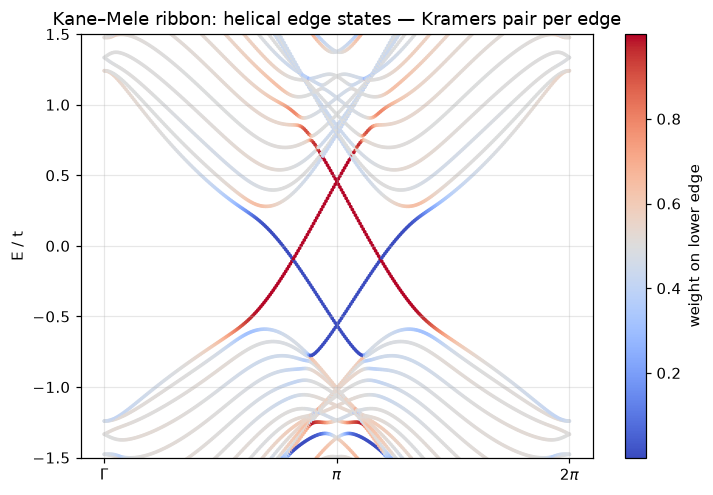

[PASS] one helical state per edge at generic in-gap k (partner at -k) — max in-gap states at one k: 2
[PASS] edge states traverse the bulk gap — in-gap states span 99% of the gap window


True

In [9]:
# helical edge states: ribbon of the topological Kane-Mele model
km = kane_mele(delta=0.7, t=1.0, soc=0.24, rashba=0.25)
rib = km.cut_piece(14, 1, glue_edges=False)
k_vec, k_dist, k_node = rib.k_path([[0.0], [0.5], [1.0]], nk=301, report=False)
ev, vec = rib.solve_ham(k_vec, return_eigvecs=True)

y_op = np.repeat(rib.orb_vecs[:, 1], 2)          # spinful: 2 states per orbital
edge_weight = np.einsum("kno,o->kn", np.abs(vec) ** 2, (y_op < y_op.mean()).astype(float))

fig, ax = plt.subplots(figsize=(7.5, 5))
sc = ax.scatter(np.repeat(k_dist, ev.shape[1]), ev.ravel(), c=edge_weight.ravel(),
                s=2, cmap="coolwarm")
fig.colorbar(sc, label="weight on lower edge")
ax.set_xticks(k_node, [r"$\Gamma$", r"$\pi$", r"$2\pi$"])
ax.set_ylabel("E / t")
ax.set_ylim(-1.5, 1.5)
ax.set_title("Kane–Mele ribbon: helical edge states — Kramers pair per edge")
plt.show()
caption("Kane–Mele ribbon bands colored by weight on the lower edge. Unlike the "
        "Haldane chiral edge (one direction per edge), each edge here carries TWO "
        "counter-propagating modes forming a Kramers pair with opposite spins — "
        "helical states. Time reversal forbids elastic backscattering between "
        "Kramers partners, so the edges conduct perfectly as long as TRS holds; "
        "a magnetic impurity would break the protection.")

# helical counting. At a FIXED k inside the bulk gap a QSH ribbon has exactly
# one edge state per edge (its Kramers partner lives at -k): two in-gap states,
# and they traverse the whole gap as k varies — that is the helical signature.
evb = km.solve_ham(km.k_uniform_mesh([40, 40]))
gap_lo, gap_hi = evb[:, 1].max(), evb[:, 2].min()
ingap = (ev > gap_lo + 0.02) & (ev < gap_hi - 0.02)
counts = ingap.sum(axis=1)
E_ingap = ev[ingap]
span = (E_ingap.max() - E_ingap.min()) / (gap_hi - gap_lo - 0.04)
check("one helical state per edge at generic in-gap k (partner at -k)",
      counts.max() == 2 and (counts == 2).sum() > 20,
      f"max in-gap states at one k: {counts.max()}")
check("edge states traverse the bulk gap", span > 0.9,
      f"in-gap states span {100*span:.0f}% of the gap window")

<a id="sec-16"></a>

## 16. The BHZ model — the quantum spin Hall quantum well, on a lattice

Bernevig–Hughes–Zhang (2006) predicted the first *observed* topological insulator: HgTe/CdTe
quantum wells. Kwant's tutorial discretizes the continuum $\mathbf{k}\cdot\mathbf{p}$ BHZ
Hamiltonian; PythTB has no discretizer (Part IV, §27), so we do what a tight-binder does — write
the standard **lattice regularization** directly on a square lattice with two orbitals
($s$, $p$) per spin:
$$
H(\mathbf k) = \begin{pmatrix} h(\mathbf k) & 0 \\ 0 & h^*(-\mathbf k)\end{pmatrix},\qquad
h(\mathbf k) = A\sin K_x\,\sigma_x + A\sin K_y\,\sigma_y +
\bigl[M - 2B(2 - \cos K_x - \cos K_y)\bigr]\sigma_z .
$$
Band inversion — and $\mathbb{Z}_2 = 1$ — occurs for $0 < M/B < 8$; $M$ is the well-thickness
knob of the experiment. Written out: the $\sigma_z\otimes s_0$ mass terms are orbital onsites and
spin-scalar hops, $A\sin K_x\,\sigma_x\otimes s_z$ and $A\sin K_y\,\sigma_y\otimes s_0$ are
orbital-off-diagonal hops with spin matrices — exactly the kind of term `set_hop` takes as a
$2\times2$ spin matrix.

In [10]:
def bhz(M, A=1.0, B=1.0):
    '''Lattice-regularized BHZ model, spinful, orbitals s and p at the same site.'''
    s0 = np.eye(2); sz = np.diag([1.0, -1.0])
    lat = Lattice(lat_vecs=[[1, 0], [0, 1]], orb_vecs=[[0, 0], [0, 0]],
                  periodic_dirs=[0, 1])
    m = TBModel(lat, spinful=True)
    # mass terms: (M - 4B) sigma_z onsite, +B sigma_z hops along x and y
    m.set_onsite([[(M - 4 * B), 0, 0, 0], [-(M - 4 * B), 0, 0, 0]])
    for R in ([1, 0], [0, 1]):
        m.set_hop(B * s0, 0, 0, R)
        m.set_hop(-B * s0, 1, 1, R)
    # A sin Kx sigma_x (orbital) x s_z (spin):  t01([1,0]) = A sz / 2i
    m.set_hop(A / (2j) * sz, 0, 1, [1, 0])
    m.set_hop(-A / (2j) * sz, 0, 1, [-1, 0], allow_conjugate_pair=True)
    # A sin Ky sigma_y (orbital) x s_0:  H01 = -iA sin Ky
    m.set_hop(-A / 2 * s0, 0, 1, [0, 1])
    m.set_hop(A / 2 * s0, 0, 1, [0, -1], allow_conjugate_pair=True)
    return m

# sanity: analytic spectrum E = +-|d(k)| twice (Kramers)
M_topo, M_triv = 1.0, -1.0
mb = bhz(M_topo)
k_test = rng.random((30, 2))
K = 2 * np.pi * k_test
d = np.stack([np.sin(K[:, 0]), np.sin(K[:, 1]),
              M_topo - 2 * 1.0 * (2 - np.cos(K[:, 0]) - np.cos(K[:, 1]))], axis=1)
E_analytic = np.sort(np.concatenate([np.linalg.norm(d, axis=1)[:, None] * s
                                     for s in (-1, -1, 1, 1)], axis=1), axis=1)
ev = np.sort(mb.solve_ham(k_test), axis=1)
check("lattice BHZ reproduces the analytic |d(k)| spectrum",
      np.allclose(ev, E_analytic, atol=1e-10),
      f"max dev = {np.abs(ev - E_analytic).max():.2e}")

[PASS] lattice BHZ reproduces the analytic |d(k)| spectrum — max dev = 4.44e-15


True

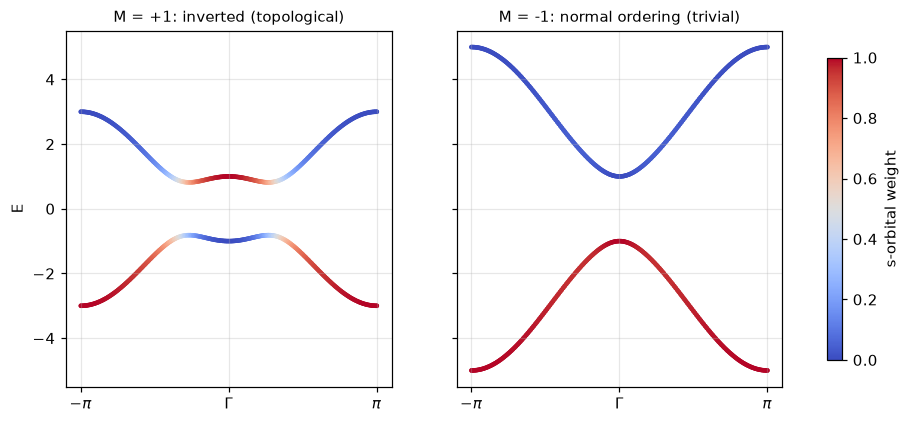

In [11]:
# the experiment's knob, visualized: BAND INVERSION. Color the bands by their
# s-orbital weight — in the trivial phase the s band stays above the p band
# everywhere; in the topological phase their characters have SWAPPED near Γ.
fig, axs = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
for ax, Mv, tag in ((axs[0], 1.0, "M = +1: inverted (topological)"),
                    (axs[1], -1.0, "M = -1: normal ordering (trivial)")):
    m = bhz(Mv)
    k_vec, k_dist, k_node = m.k_path([[-0.5, 0], [0, 0], [0.5, 0]], nk=201, report=False)
    ev_i, vec_i = m.solve_ham(k_vec, return_eigvecs=True)
    # weight on orbital 0 (the 's' band): spinful states are (norb x 2) flattened
    w_s = (np.abs(vec_i) ** 2).reshape(len(k_vec), 4, 2, 2)[:, :, 0, :].sum(-1)
    sc = ax.scatter(np.repeat(k_dist, 4), ev_i.ravel(), c=w_s.ravel(), s=4,
                    cmap="coolwarm", vmin=0, vmax=1)
    ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
    ax.set_title(tag, fontsize=10)
axs[0].set_ylabel("E")
fig.colorbar(sc, ax=axs, label="s-orbital weight", shrink=0.85)
plt.show()
caption("Band inversion, the mechanism behind the BHZ prediction: bands along "
        "kx colored by s-orbital character. For M < 0 (right) the s-like band "
        "(red) lies entirely above the p-like band (blue) — an ordinary "
        "semiconductor. For M > 0 (left) the characters are exchanged in a "
        "neighbourhood of Γ: the bands have inverted, and no local perturbation can "
        "undo the exchange without closing the gap. In HgTe quantum wells the knob "
        "M is the well thickness, and the inversion happens at d ≈ 6.3 nm.")

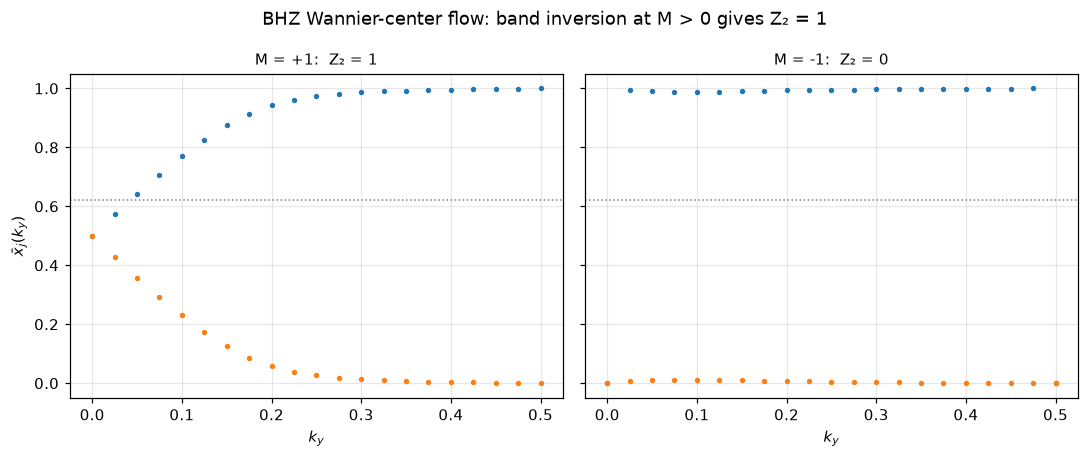

[PASS] BHZ is topological for 0 < M/B < 8 and trivial for M < 0


True

In [12]:
# Z2 via Wannier-center flow, for both signs of M
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
z2_bhz = {}
for ax, Mv in zip(axs, (M_topo, M_triv)):
    m = bhz(Mv)
    mesh = Mesh(["k", "k"])
    mesh.build_grid((51, 41), k_endpoints=[True, True])
    wfa = WFArray(m.lattice, mesh, spinful=True)
    wfa.solve_model(m)
    wcc = np.asarray(wfa.berry_phase(axis_idx=0, state_idx=[0, 1],
                                     berry_evals=True, contin=False)) / (2 * np.pi) % 1.0
    ky = mesh.get_axis_range(1, 1)
    half = ky <= 0.5 + 1e-9
    for j in range(wcc.shape[1]):
        ax.plot(ky[half], wcc[half, j], "o", ms=2.5)
    ref = 0.62
    z2_bhz[Mv], crossings = z2_from_wcc(wcc[half], ref)   # helper from §15
    ax.axhline(ref, color="gray", ls=":", lw=1)
    ax.set_title(f"M = {Mv:+.0f}:  Z₂ = {crossings % 2}", fontsize=10)
    ax.set_xlabel(r"$k_y$")
axs[0].set_ylabel(r"$\bar x_j(k_y)$")
fig.suptitle("BHZ Wannier-center flow: band inversion at M > 0 gives Z₂ = 1")
fig.tight_layout()
plt.show()
caption("The same Wannier-flow diagnostic applied to the BHZ model: partner "
        "switching (left, odd crossings of the reference line) for the inverted "
        "regime, none for the normal one. The Z₂ index sees the band inversion of "
        "the previous figure without ever looking at orbital character — invariants "
        "do not care how the topology was engineered.")

check("BHZ is topological for 0 < M/B < 8 and trivial for M < 0",
      z2_bhz[M_topo] == 1 and z2_bhz[M_triv] == 0)

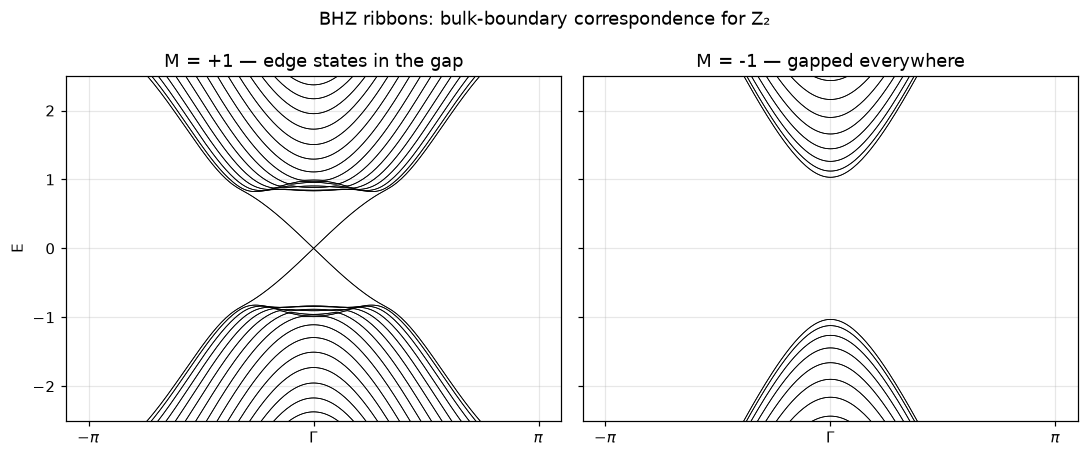

In [13]:
# the experimental signature: helical edge states appear only in the inverted regime
fig, axs = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, Mv in zip(axs, (M_topo, M_triv)):
    rib = bhz(Mv).cut_piece(20, 1, glue_edges=False)
    k_vec, k_dist, k_node = rib.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
    ev = rib.solve_ham(k_vec)
    ax.plot(k_dist, ev, "k-", lw=0.5)
    ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
    ax.set_ylim(-2.5, 2.5)
    ax.set_title(f"M = {Mv:+.0f} — {'edge states in the gap' if Mv > 0 else 'gapped everywhere'}")
axs[0].set_ylabel("E")
fig.suptitle("BHZ ribbons: bulk-boundary correspondence for Z₂")
fig.tight_layout()
plt.show()
caption("BHZ ribbon spectra in the two phases. Only the inverted regime (left) "
        "carries states crossing the bulk gap — the helical edge channels whose "
        "quantized conductance 2e²/h was measured by the Würzburg group in 2007, "
        "the first experimental topological insulator. The trivial ribbon (right) "
        "is gapped through and through.")

In [14]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 4 — checks passed : {_CHECKS['pass']}")
print(f"chapter 4 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 4 — checks passed : 10
chapter 4 — checks failed : 0
wall time                 : 12 s
Every quantitative claim in this notebook was verified in this run.
